In [1]:
import animate as an
import makelines as ml
import numpy as np
from matplotlib import pyplot as plt
import timeit
from IPython.display import Video,display
import networkx as nx
import os
import pickle

In three dimensions, it seems that frozen spirals only seem to appear often below the Benjamin Feir line $bc<1$. This may be because of instabilities of the spiral cores with perturbation wavevector along the length of the defect line, as we seem to see helical oscillations appear in simulations.

Plot the final state faces for running or complete simulations

./rdcu -s 1 -t 2000.000000 -d 0.100000 -N 128,128,128 -L 200.000000,200.000000,200.000000 -s 100 -n 2 -D1 -R scratch/3dcgle/11/11/ 

runtime: 82.010540

b=2.000000, c=0.571429
final time: 2000.000000


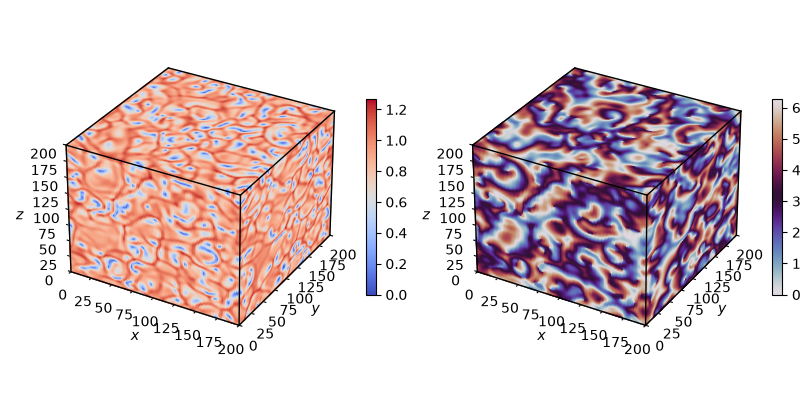

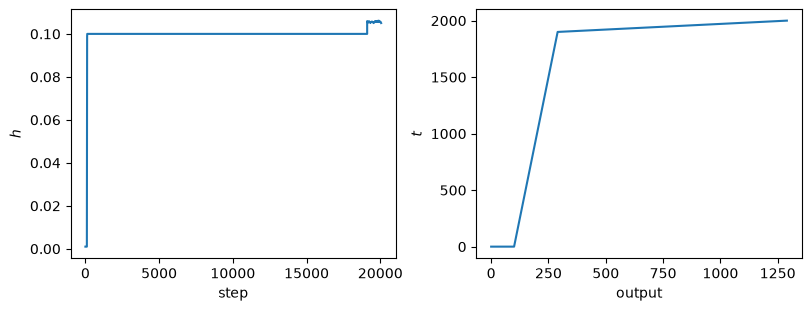

In [2]:
Ns=np.array([128,128,128])
Ls=np.array([200.,200.,200.])
N=np.prod(Ns)

filebase='scratch/3dcgle/11/11/'

file=open('%s.out'%(filebase),'r')
sts=file.readlines()
file.close()
print(sts[0])
print(sts[-1])
file=open('%scoupling.dat'%(filebase),'r')
sts=file.readlines()
file.close()
b=-float(sts[5].split(',')[0])
c=float(sts[18].split(',')[0])
print('b=%f, c=%f'%(b,c))
ys=np.fromfile('%sfs.dat'%(filebase),dtype=float)[:2*N].reshape([2]+Ns.tolist())
ts=np.fromfile('%stimes.dat'%(filebase),dtype=float)
hs=np.fromfile('%ssteps.dat'%(filebase),dtype=float)

print("final time: %f"%(ts[-1]))
faces=[[ys[:,0,:,:],ys[:,:,0,:],ys[:,:,:,0],ys[:,-1,:,:],ys[:,:,-1,:],ys[:,:,:,-1]]]
Rmax=np.max(np.linalg.norm(faces,axis=2))
lines=None
n=0

an.makeplot(n, Ns, Ls, faces=faces, lines=lines, Rmax=Rmax, show=True, save=False)

ts=np.fromfile('%stimes.dat'%(filebase),dtype=float)
hs=np.fromfile('%ssteps.dat'%(filebase),dtype=float)

plt.subplots(1,2,figsize=(8,3),layout='constrained')
plt.subplot(1,2,1)
plt.plot(hs)
# plt.yscale('log')
plt.xlabel('step')
plt.ylabel(r'$h$')
plt.subplot(1,2,2)
plt.plot(ts)
plt.xlabel('output')
plt.ylabel(r'$t$')
plt.show()

Make and plot the final state lines for running or complete simulations

savelines 0
31.884822277817875


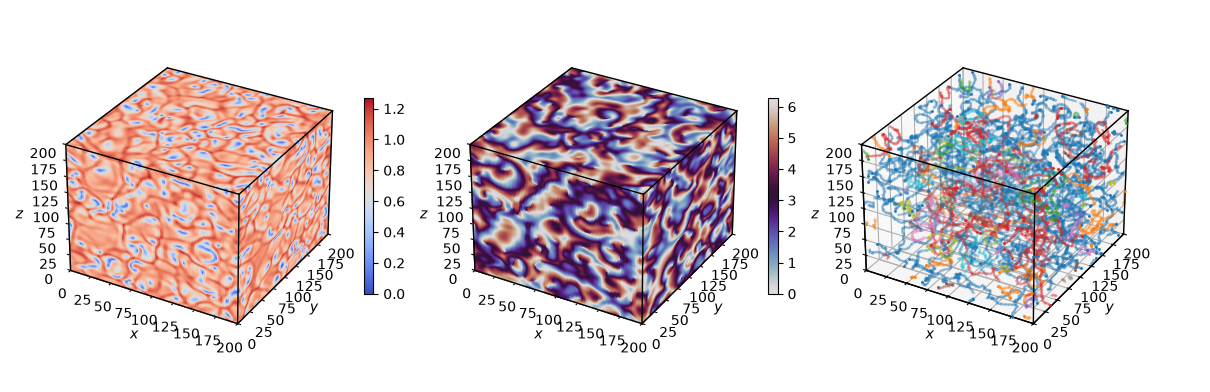

25.06420353287831


In [3]:
start=timeit.default_timer()
line=ml.savelines(0,'%sfs.dat'%(filebase),Ns,Ls,0,1024)
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
an.makeplot(0, Ns, Ls, faces=faces, lines=[line], cids=[[i%len(an.colors) for i in range(len(line))]], Rmax=Rmax, show=True, save=False)
stop=timeit.default_timer()
print(stop-start)

savelines 0
4.922600424848497


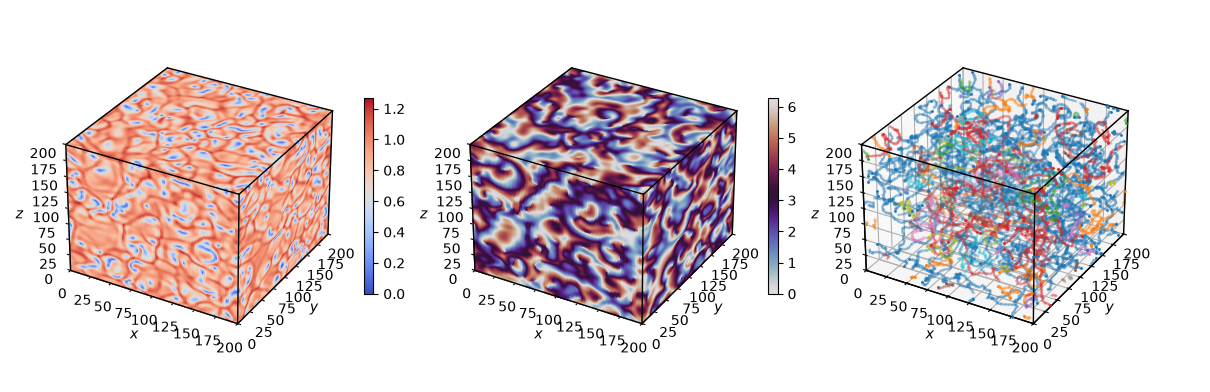

25.420474351383746


In [11]:
import importlib as imp
import makelines2 as ml2
imp.reload(ml2)

start=timeit.default_timer()
line=ml2.savelines(0,'%sfs.dat'%(filebase),Ns,Ls,0,1024)
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
an.makeplot(0, Ns, Ls, faces=faces, lines=[line], cids=[[i%len(an.colors) for i in range(len(line))]], Rmax=Rmax, show=True, save=False)
stop=timeit.default_timer()
print(stop-start)

load the saved lines for complete simulations

In [12]:
file=open('%slines.dat'%filebase, 'rb')
lines=pickle.load(file)
file.close()

file=open('%sdiffs.dat'%filebase, 'rb')
diffs=pickle.load(file)
file.close()

file=open('%slineids.dat'%filebase, 'rb')
ids,cids,edges=pickle.load(file)
file.close()
nt=len(lines)

In [19]:
n=1
chunk=4096
start=timeit.default_timer()
test=ml.correlate(n,lines,Ns,Ls,chunk)
stop=timeit.default_timer()
print(stop-start)


correlate 1
37.37113462993875


In [20]:
import importlib as imp
import makelines2 as ml2
imp.reload(ml2)

chunk=4096
start=timeit.default_timer()
test2=ml2.correlate(n,lines,Ns,Ls,chunk)
stop=timeit.default_timer()
print(stop-start)


correlate 1
16.997129410970956


plot the ancestry graph

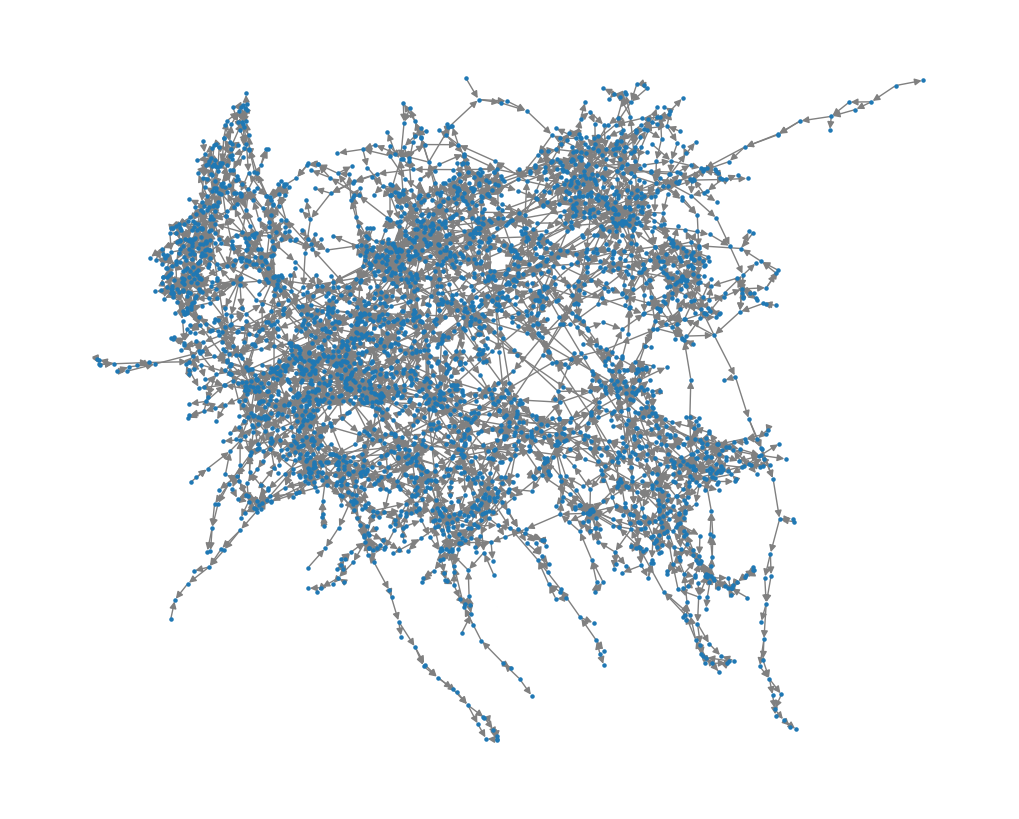

In [91]:
G=nx.DiGraph(edges)
plt.figure(figsize=(10, 8))
nx.draw(G,node_size=5,edge_color='gray')
plt.show()

plot the line ancestry as a directed acyclic graph

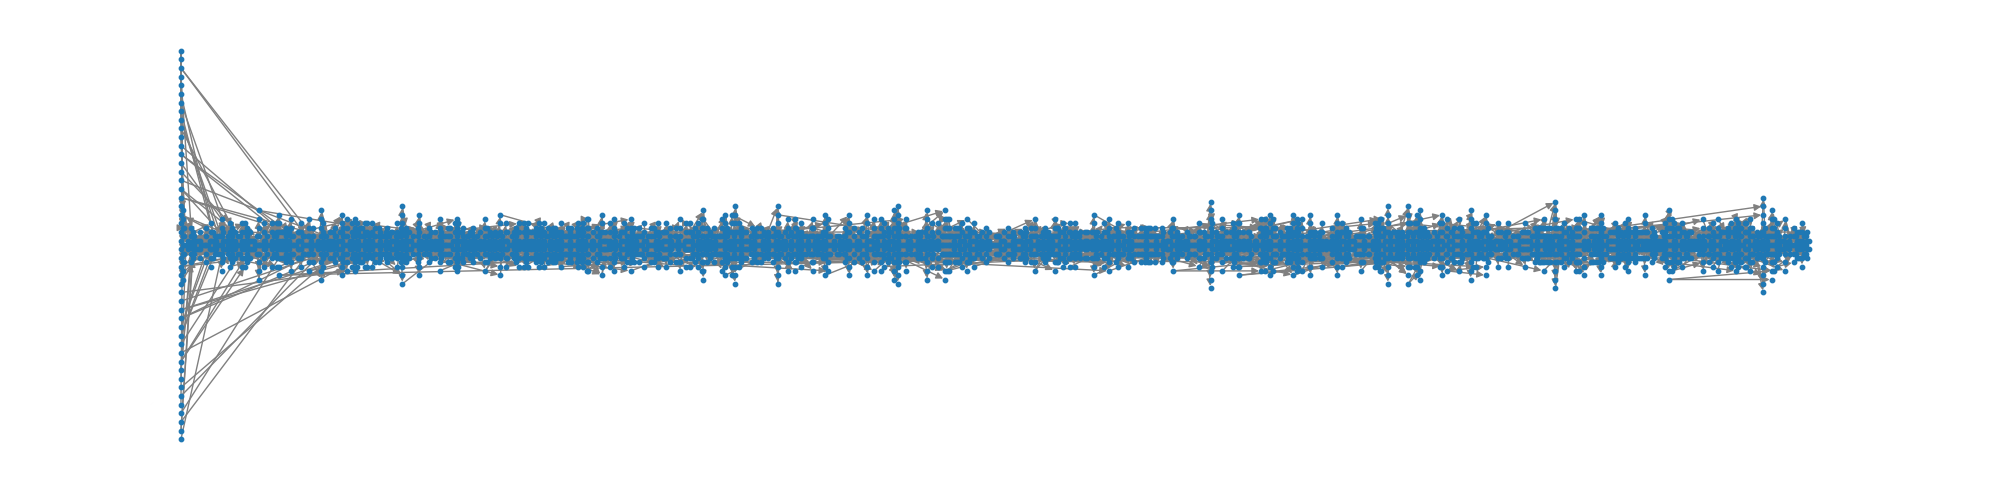

In [92]:
G=nx.DiGraph(edges)

for node in G.nodes:
    for n in range(len(lines)):
        if len(np.where(ids[n]==node)[0])>0:
            break
    G.nodes[node]["birth"] = n

pos = nx.multipartite_layout(G, subset_key="birth", align='vertical')
for key in pos.keys():
    oldval=pos[key]
    newval=np.array([oldval[0],-oldval[1]])
    pos[key]=newval
    
plt.figure(figsize=(20, 5))
nx.draw_networkx(G,pos=pos,with_labels=False,edge_color='gray',node_size=10)

plt.axis("off")
plt.tight_layout()
plt.show()

plot the lines

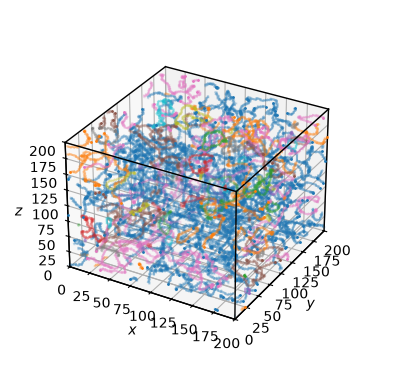

20.74159861775115


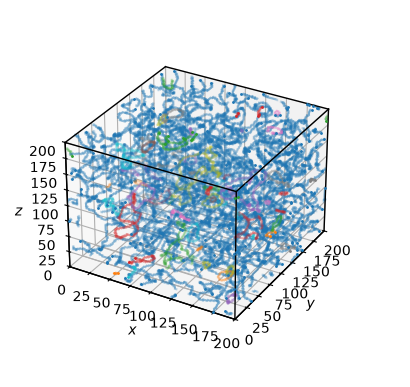

21.76344713009894


In [93]:
faces=None

start=timeit.default_timer()
an.makeplot(0, Ns, Ls, faces=None, lines=lines, cids=cids, show=True, save=False)
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
an.makeplot(nt-1, Ns, Ls, faces=None, lines=lines, cids=cids, show=True, save=False)
stop=timeit.default_timer()
print(stop-start)

look at a steps where the longest line changed

In [94]:
file=open(filebase+'diffs.dat','rb')
diffs=pickle.load(file)
file.close()

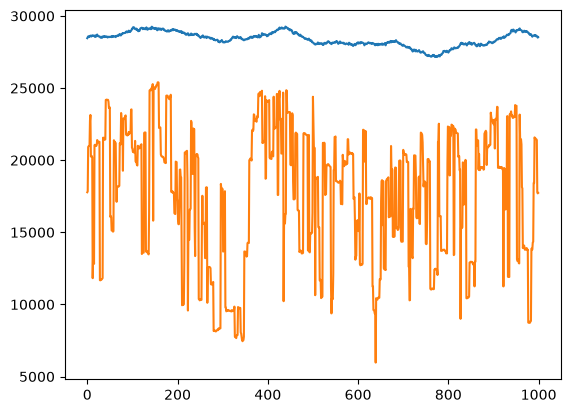

In [95]:
plt.plot([np.sum([len(l) for l in ls]) for ls in lines])
plt.plot([np.max([len(l) for l in ls]) for ls in lines])

In [96]:
n=np.where(np.abs(np.diff([np.max([len(l) for l in ls]) for ls in lines]))>500)[0][0]
ls=np.array([len(l) for l in lines[n]])
order=np.argsort(ls)
print(ls[order[-2:]])
print(order[-2:])
print(diffs[n][order[-2:]])

[ 3016 17842]
[5 0]
[[  9  23  29  20  35  12  86  32 128   6 116 124  95 128  93 128  98 128
   68 104 128  94  91 128  99 128  69 108  90 128 128  62 102 128 128  84
  106 128 128 128 128 128 115 128 128 128 128  96 128 128 128 128 128 128
  128 128 128 128 128 128 128 128 128 128 128 128 128 128 128 128 128]
 [  0   4   5   8   3   0   4  10   6   8   6   4   7   2   9   6   9   9
    7   6   6   4   8   4   6   6   2   6   8   8   4   4   3   4   9   3
   10   7   8   0  10   5   5   7   7   5   5   6  10   6   2   8   6   6
    5   9   5   9  12   8   3   3   9   8   4   3   8   6   4   4   6]]


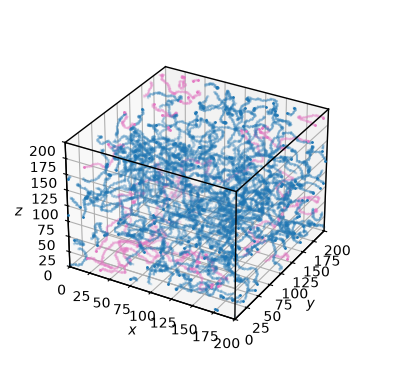

14.971824307926


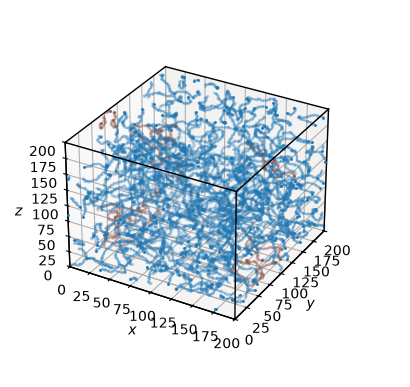

16.910298126749694


In [97]:
start=timeit.default_timer()
ls=np.array([len(l) for l in lines[n]])
order=np.argsort(ls)
an.makeplot(0, Ns, Ls, faces=None, lines=[[lines[n][order[-2]],lines[n][order[-1]]]], cids=[cids[n][order[-2:]]], show=True, save=False)
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
ls=np.array([len(l) for l in lines[n+1]])
order=np.argsort(ls)
an.makeplot(0, Ns, Ls, faces=None, lines=[[lines[n+1][order[-2]],lines[n+1][order[-1]]]], cids=[cids[n+1][order[-2:]]], show=True, save=False)
stop=timeit.default_timer()
print(stop-start)

plot the lines alongside the saved faces of the fields

In [98]:
file=open("%sfaces.dat"%(filebase),"rb")
faces=pickle.load(file)
file.close()
Rmax=np.max(faces)

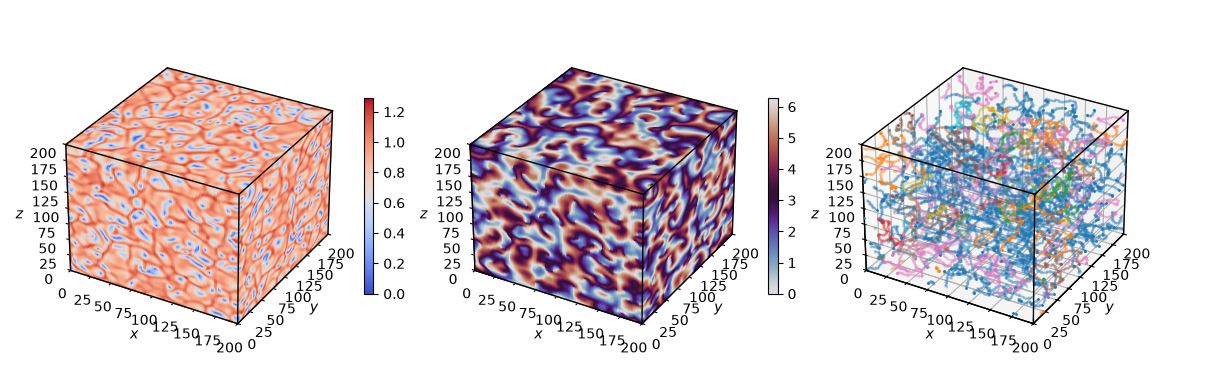

26.008310505654663


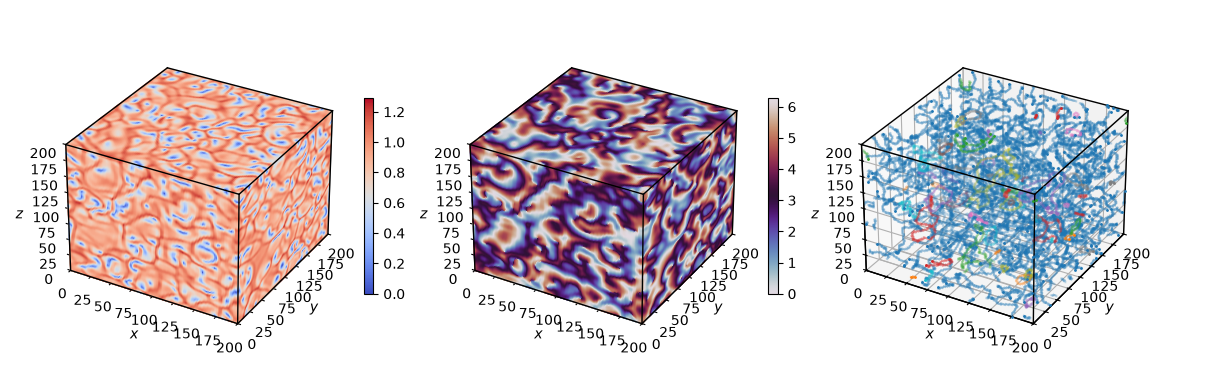

25.88142975093797


In [101]:
start=timeit.default_timer()
an.makeplot(0, Ns, Ls, faces, lines, cids, Rmax, show=True, save=False)
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
an.makeplot(nt-1, Ns, Ls, faces, lines, cids, Rmax, show=True, save=False)
stop=timeit.default_timer()
print(stop-start)

In [100]:
if os.path.exists('%sanimation.mp4'%(filebase)):
    display(Video('%sanimation.mp4'%(filebase)))